In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [2]:
# Load the breast cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f"Dataset shape: {X.shape}")
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"\nTarget values: {y.unique()}")
print(f"0 = Malignant (Cancer), 1 = Benign (No Cancer)")

Dataset shape: (569, 30)
Features: 30
Samples: 569

Target values: [0 1]
0 = Malignant (Cancer), 1 = Benign (No Cancer)


In [3]:
# Check for missing values
print(f"Missing values: {X.isnull().sum().sum()}")

# Display statistics
print(f"\nDataset Statistics:")
print(X.describe())

# Class distribution
print(f"\nClass Distribution:")
print(y.value_counts())

Missing values: 0

Dataset Statistics:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.0

In [4]:
# Handle missing values
X = X.fillna(X.mean())

# Scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("✓ Data preprocessing complete!")
print(f"\nScaled data statistics:")
print(X_scaled.describe())

✓ Data preprocessing complete!

Scaled data statistics:
        mean radius  mean texture  mean perimeter     mean area  \
count  5.690000e+02  5.690000e+02    5.690000e+02  5.690000e+02   
mean  -1.373633e-16  6.868164e-17   -1.248757e-16 -2.185325e-16   
std    1.000880e+00  1.000880e+00    1.000880e+00  1.000880e+00   
min   -2.029648e+00 -2.229249e+00   -1.984504e+00 -1.454443e+00   
25%   -6.893853e-01 -7.259631e-01   -6.919555e-01 -6.671955e-01   
50%   -2.150816e-01 -1.046362e-01   -2.359800e-01 -2.951869e-01   
75%    4.693926e-01  5.841756e-01    4.996769e-01  3.635073e-01   
max    3.971288e+00  4.651889e+00    3.976130e+00  5.250529e+00   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count     5.690000e+02      5.690000e+02    5.690000e+02         5.690000e+02   
mean     -8.366672e-16      1.873136e-16    4.995028e-17        -4.995028e-17   
std       1.000880e+00      1.000880e+00    1.000880e+00         1.000880e+00   
min      -3.1120

In [5]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nTraining labels: {y_train.value_counts().to_dict()}")
print(f"Testing labels: {y_test.value_counts().to_dict()}")

Training set: 455 samples
Testing set: 114 samples

Training labels: {1: 285, 0: 170}
Testing labels: {1: 72, 0: 42}


In [6]:
# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("✓ Logistic Regression trained!")
print(f"Predictions shape: {y_pred_lr.shape}")

✓ Logistic Regression trained!
Predictions shape: (114,)


In [7]:
# Train SVM
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("✓ SVM model trained!")

✓ SVM model trained!


In [9]:
 #Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("✓ Decision Tree trained!")

✓ Decision Tree trained!


In [10]:
# Evaluate models
def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{'='*40}")
    print(f"{model_name}")
    print(f"{'='*40}")
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    return accuracy, precision, recall, f1

# Evaluate all
acc_lr, prec_lr, rec_lr, f1_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr)
acc_svm, prec_svm, rec_svm, f1_svm = evaluate_model("SVM", y_test, y_pred_svm)
acc_dt, prec_dt, rec_dt, f1_dt = evaluate_model("Decision Tree", y_test, y_pred_dt)


Logistic Regression
Accuracy:  0.9825 (98.25%)
Precision: 0.9861
Recall:    0.9861
F1-Score:  0.9861

SVM
Accuracy:  0.9825 (98.25%)
Precision: 0.9861
Recall:    0.9861
F1-Score:  0.9861

Decision Tree
Accuracy:  0.9123 (91.23%)
Precision: 0.9559
Recall:    0.9028
F1-Score:  0.9286


In [11]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree'],
    'Accuracy': [acc_lr, acc_svm, acc_dt],
    'Precision': [prec_lr, prec_svm, prec_dt],
    'Recall': [rec_lr, rec_svm, rec_dt],
    'F1-Score': [f1_lr, f1_svm, f1_dt]
})

print("\nModel Comparison:")
print(comparison_df.to_string(index=False))

# Find best
best_idx = comparison_df['Accuracy'].idxmax()
print(f"\n🏆 Best Model: {comparison_df.loc[best_idx, 'Model']}")
print(f"   Accuracy: {comparison_df.loc[best_idx, 'Accuracy']*100:.2f}%")


Model Comparison:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.982456   0.986111 0.986111  0.986111
                SVM  0.982456   0.986111 0.986111  0.986111
      Decision Tree  0.912281   0.955882 0.902778  0.928571

🏆 Best Model: Logistic Regression
   Accuracy: 98.25%


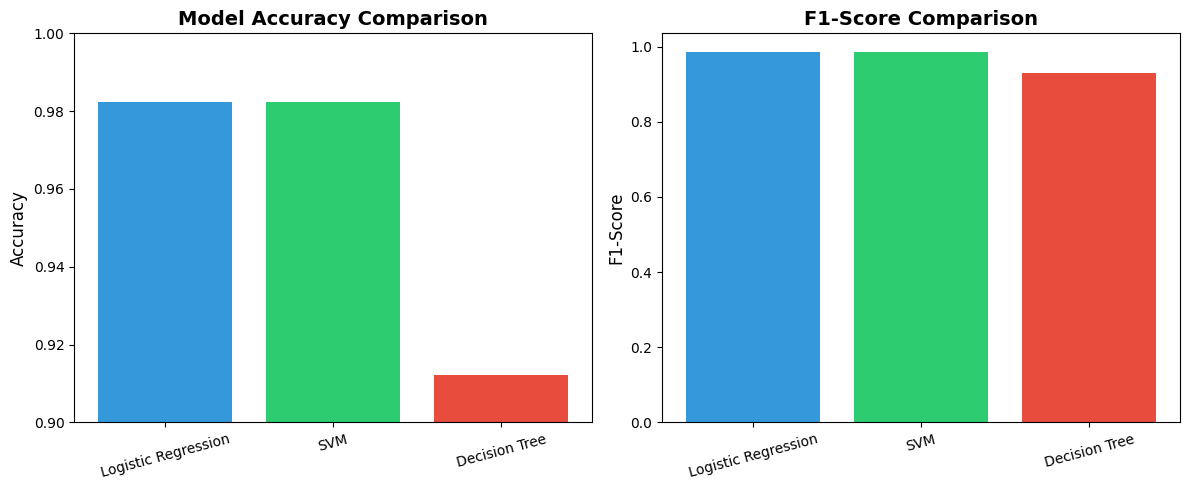

✓ Visualizations created!


In [12]:
# Create comparison charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy chart
ax1 = axes[0]
ax1.bar(comparison_df['Model'], comparison_df['Accuracy'], color=['#3498db', '#2ecc71', '#e74c3c'])
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim([0.9, 1.0])
ax1.tick_params(axis='x', rotation=15)

# F1-Score chart
ax2 = axes[1]
ax2.bar(comparison_df['Model'], comparison_df['F1-Score'], color=['#3498db', '#2ecc71', '#e74c3c'])
ax2.set_ylabel('F1-Score', fontsize=12)
ax2.set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("✓ Visualizations created!")